In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

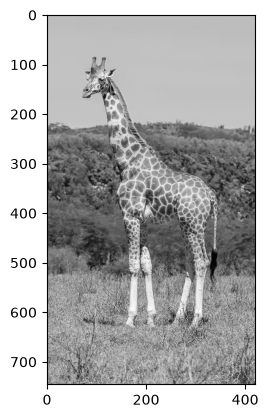

In [2]:
image=cv2.imread("giraffe.jpg",cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.show()

In [3]:
def add_salt_pepper_noise(image,probability=0.3):
    noisy=image.copy()
    random= np.random.rand(*image.shape)
    noisy[random<probability/2]=0
    noisy[random>1-probability/2]=255
    return noisy

<function matplotlib.pyplot.show(close=None, block=None)>

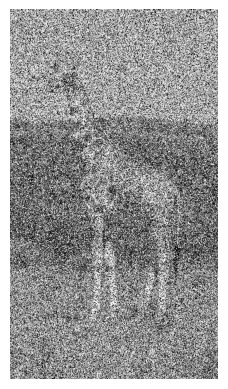

In [4]:
prob=0.5
noisy=add_salt_pepper_noise(image,prob)
plt.imshow(noisy, cmap='gray')
plt.axis("off")
plt.show

In [5]:



def mean_filter(image, kernel_size=3, stride=1):

    rows, cols = image.shape

    pad = kernel_size // 2

    padded = np.pad(image, pad, mode='reflect')

    output = np.zeros((rows, cols), dtype=np.uint8)

    for i in range(0, rows, stride):
        for j in range(0, cols, stride):

            total = 0

            for m in range(kernel_size):
                for n in range(kernel_size):

                    total += int(padded[i+m][j+n])

            mean = total // (kernel_size * kernel_size)

            output[i][j] = mean

    return output

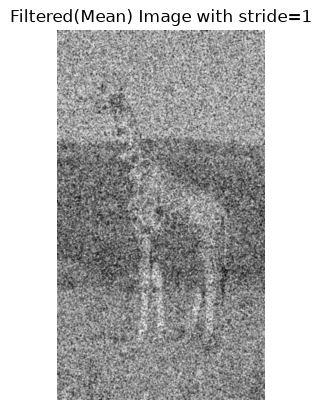

In [6]:
mean1=mean_filter(noisy, kernel_size=3, stride=1)
plt.imshow(mean1, cmap='gray')
plt.title("Filtered(Mean) Image with stride=1")
plt.axis("off")
plt.show()

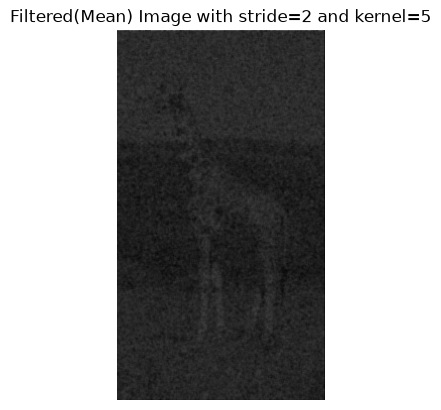

In [7]:
mean2=mean_filter(noisy, kernel_size=5, stride=2)
plt.imshow(mean2, cmap='gray')
plt.title("Filtered(Mean) Image with stride=2 and kernel=5")
plt.axis("off")
plt.show()

In [8]:


def median_filter(image, kernel_size=3, stride=1):

    rows, cols = image.shape

    pad = kernel_size // 2

    padded = np.pad(image, pad, mode='reflect')

    output = np.zeros((rows, cols), dtype=np.uint8)

    for i in range(0, rows, stride):
        for j in range(0, cols, stride):

            values = []

            for m in range(kernel_size):
                for n in range(kernel_size):

                    values.append(int(padded[i+m][j+n]))

            values.sort()

            median = values[len(values)//2]

            output[i][j] = median

    return output

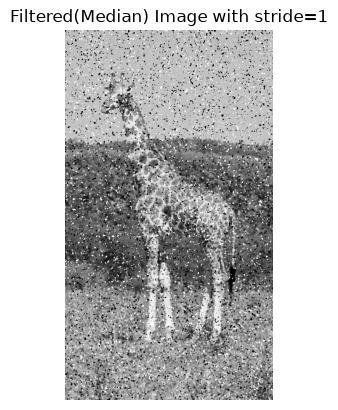

In [9]:
median1=median_filter(noisy, kernel_size=3, stride=1)
plt.imshow(median1, cmap='gray')
plt.title("Filtered(Median) Image with stride=1")
plt.axis("off")
plt.show()

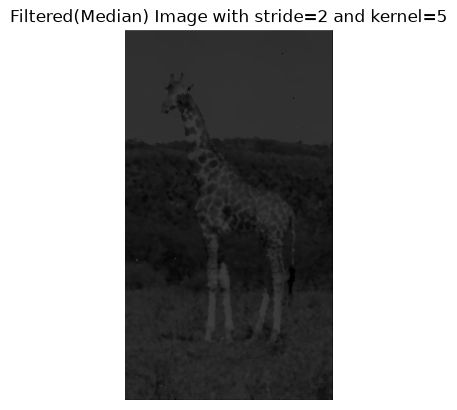

In [12]:
median2=median_filter(noisy, kernel_size=7, stride=2)
plt.imshow(median2, cmap='gray')
plt.title("Filtered(Median) Image with stride=2 and kernel=5")
plt.axis("off")
plt.show()